In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
data=pd.read_csv('car_price_prediction.csv')
data.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [15]:
print(data.shape)

(19237, 18)


In [16]:
print(data.columns)

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='str')


In [17]:
#Checking missing values
data.isnull().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [18]:
data = data.drop("ID", axis=1)

In [19]:
print(data.columns)

Index(['Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year', 'Category',
       'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='str')


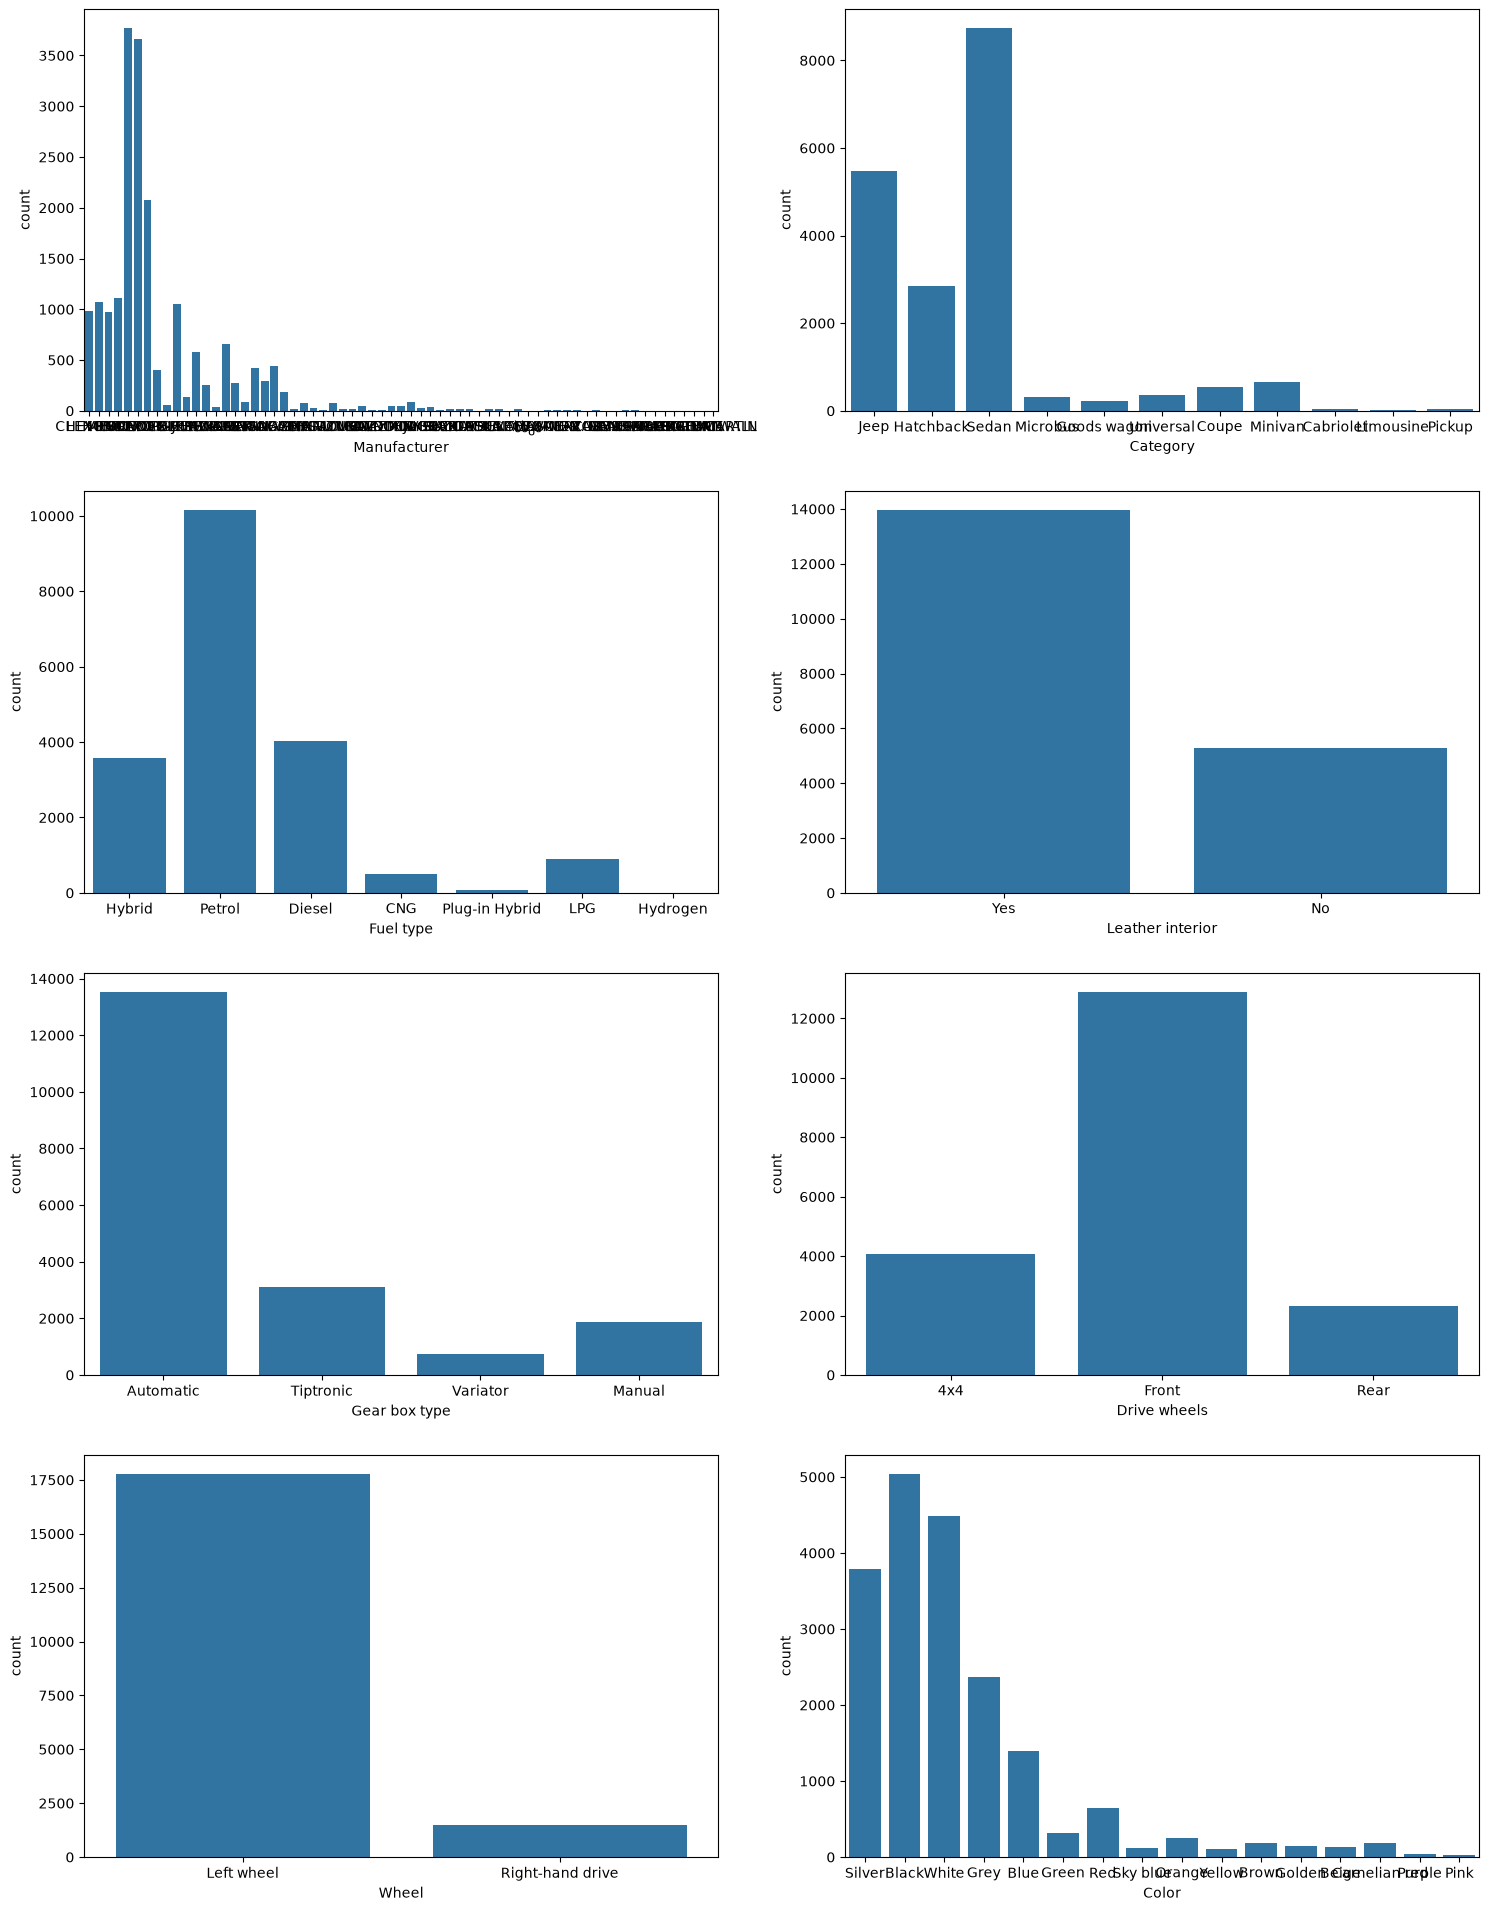

In [20]:
#Plotting the data
plt.figure(figsize=(18, 24))

columns = [
    'Manufacturer',
    'Category',
    'Fuel type',
    'Leather interior',
    'Gear box type',
    'Drive wheels',
    'Wheel',
    'Color'
]

for i, col in enumerate(columns):
    plt.subplot(4, 2, i + 1)
    sns.countplot(data=data, x=col)

In [21]:
#Data Cleaning Levy
data["Levy"] = data["Levy"].replace("-", np.nan)
data["Levy"] = pd.to_numeric(data["Levy"], errors="coerce")

In [22]:
#Mileage
data["Mileage"] = data["Mileage"].str.replace(" km", "", regex=False)
data["Mileage"] = pd.to_numeric(data["Mileage"], errors="coerce")

In [23]:
#Engine volume
data["Engine volume"] = data["Engine volume"].str.replace(" Turbo", "", regex=False)
data["Engine volume"] = pd.to_numeric(data["Engine volume"], errors="coerce")

In [24]:
data.fillna(data.median(numeric_only=True), inplace=True)

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,13328,1399.0,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,8467,781.0,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,3607,862.0,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,11726,446.0,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,8467,781.0,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0,300000,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,15681,831.0,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,26108,836.0,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2.0,116365,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,5331,1288.0,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2.0,51258,4.0,Automatic,Front,04-May,Left wheel,Black,4


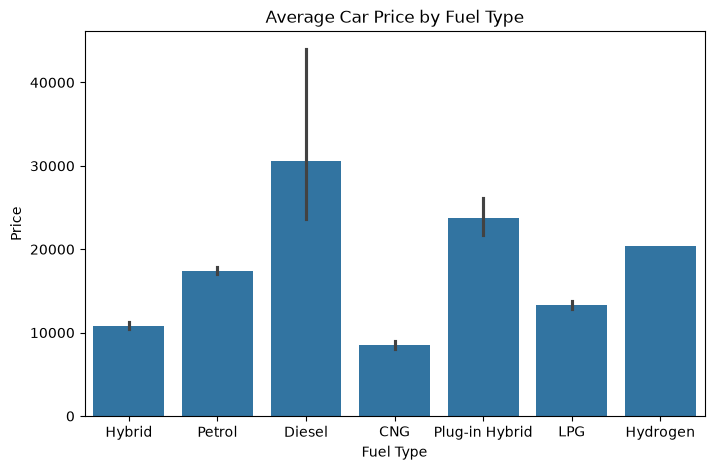

In [25]:
#Plotting relation between Fuel type and Price
plt.figure(figsize=(8,5))

sns.barplot(data=data, x='Fuel type', y='Price')

plt.title('Average Car Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price')

plt.show()

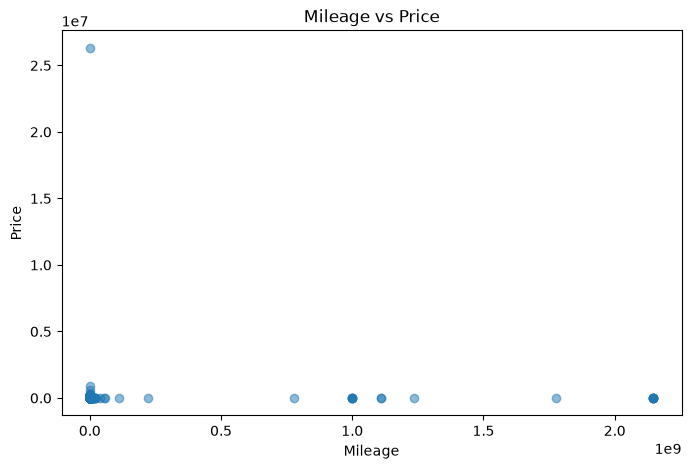

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(data["Mileage"], data["Price"], alpha=0.5)
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Mileage vs Price")
plt.show()

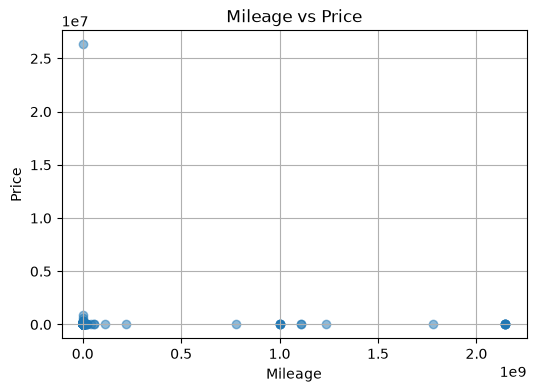

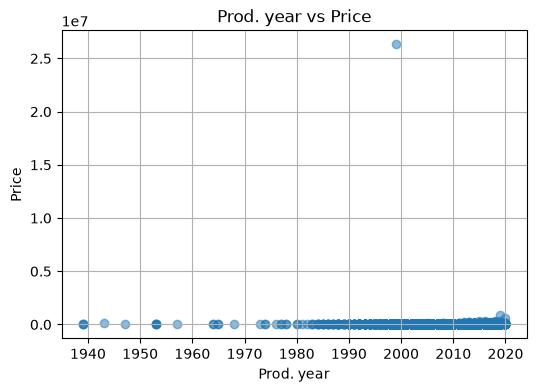

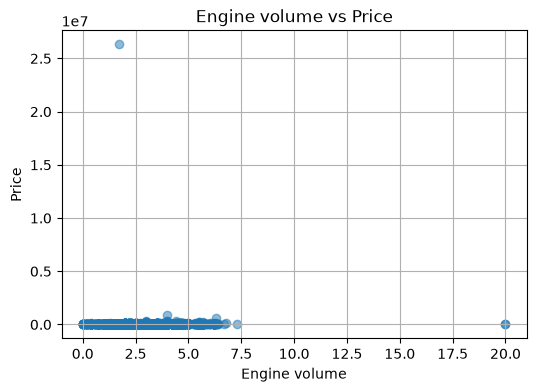

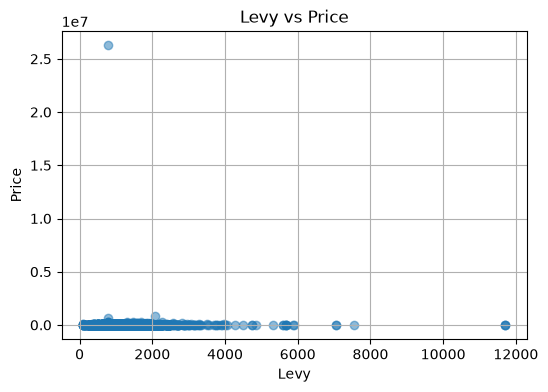

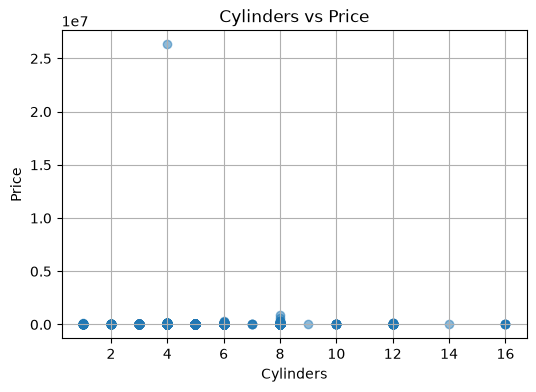

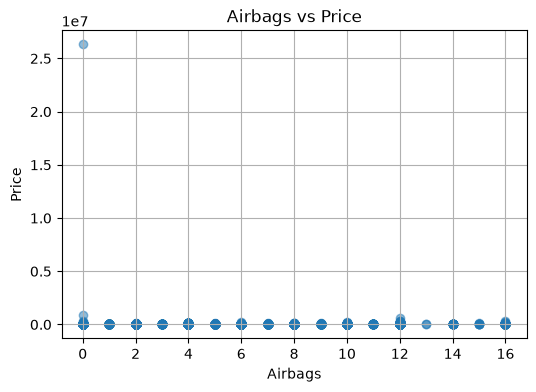

In [27]:
#seeing relationship between each numerical vallu with price 

numerical_features = [
    'Mileage',
    'Prod. year',
    'Engine volume',
    'Levy',
    'Cylinders',
    'Airbags'
]

for feature in numerical_features:
    plt.figure(figsize=(6,4))
    plt.scatter(data[feature], data['Price'], alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel('Price')
    plt.title(f'{feature} vs Price')
    plt.grid(True)
    plt.show()

In [28]:
#To see correlation
numerical_features= [ 'Mileage','Prod. year','Engine volume','Levy','Cylinders','Airbags','Price']
print(data[numerical_features].corr()['Price'].sort_values(ascending=False)
      )

Price            1.000000
Prod. year       0.012982
Engine volume    0.008753
Cylinders        0.007518
Levy             0.003828
Mileage         -0.001758
Airbags         -0.012824
Name: Price, dtype: float64


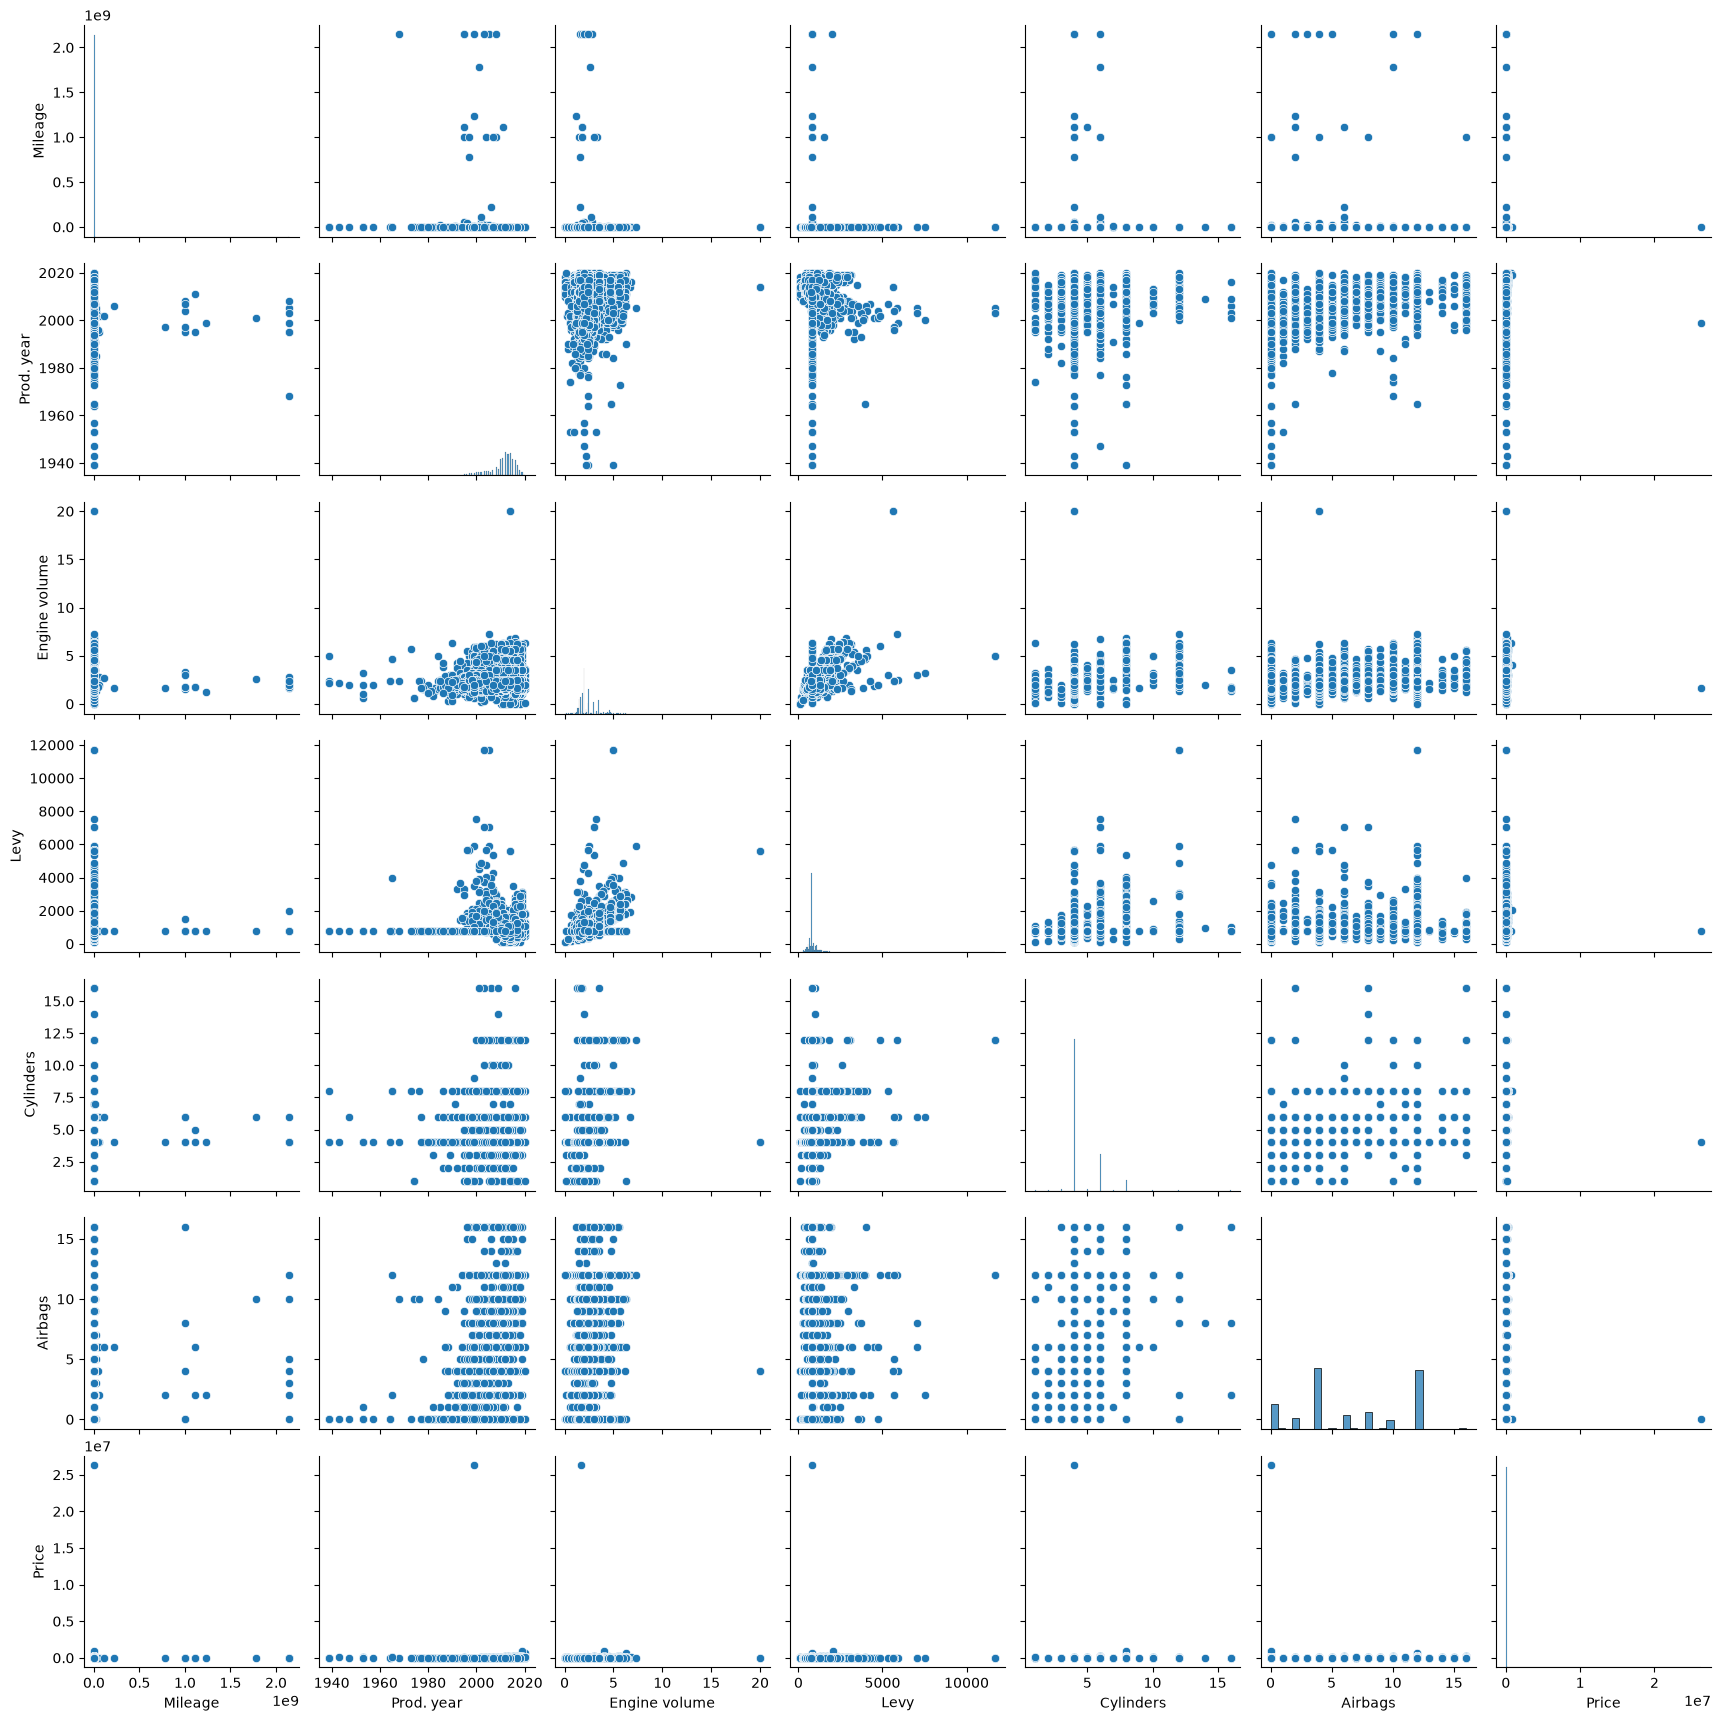

In [29]:
import seaborn as sns

sns.pairplot(
    data[['Mileage', 'Prod. year', 'Engine volume', 'Levy',
          'Cylinders', 'Airbags', 'Price']]
)
plt.show()

In [30]:
#Importing the models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [31]:
#Data Processing and Splitting
from sklearn.model_selection import train_test_split
#cross validation
from sklearn.model_selection import cross_val_score, GridSearchCV
#metrics
import sklearn.metrics as metrics
import xgboost as xgb
import category_encoders as ce
import warnings
warnings.filterwarnings(action='ignore')

In [32]:
#identify the category columns
categorical_cols=data.select_dtypes(include=['object']).columns
categorical_cols

Index(['Manufacturer', 'Model', 'Category', 'Leather interior', 'Fuel type',
       'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color'],
      dtype='str')

In [33]:
for col in categorical_cols:
    print(f"{col}:{data[col].unique()}")

Manufacturer:<ArrowStringArray>
[        'LEXUS',     'CHEVROLET',         'HONDA',          'FORD',
       'HYUNDAI',        'TOYOTA', 'MERCEDES-BENZ',          'OPEL',
       'PORSCHE',           'BMW',          'JEEP',    'VOLKSWAGEN',
          'AUDI',       'RENAULT',        'NISSAN',        'SUBARU',
        'DAEWOO',           'KIA',    'MITSUBISHI',     'SSANGYONG',
         'MAZDA',           'GMC',          'FIAT',      'INFINITI',
    'ALFA ROMEO',        'SUZUKI',         'ACURA',       'LINCOLN',
           'VAZ',           'GAZ',       'CITROEN',    'LAND ROVER',
          'MINI',         'DODGE',      'CHRYSLER',        'JAGUAR',
         'ISUZU',         'SKODA',      'DAIHATSU',         'BUICK',
         'TESLA',      'CADILLAC',       'PEUGEOT',       'BENTLEY',
         'VOLVO',          'სხვა',         'HAVAL',        'HUMMER',
         'SCION',           'UAZ',       'MERCURY',           'ZAZ',
         'ROVER',          'SEAT',        'LANCIA',      'MOSKVICH',
  

In [34]:
#Encoding categorical columns
encoder = LabelEncoder()

cat_cols = [
    "Manufacturer",
    "Model",
    "Category",
    "Leather interior",
    "Fuel type",
    "Gear box type",
    "Drive wheels",
    "Doors",
    "Wheel",
    "Color"
]

for col in cat_cols:
    data[col] = encoder.fit_transform(data[col].astype(str))

In [37]:
x = data.drop([ "Price"], axis=1)
y = data["Price"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

In [40]:
x.head()

,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,1399.0,32,1242,2010,4,1,2,3.5,186005,6.0,0,0,1,0,12,12
1,1018.0,8,658,2011,4,0,5,3.0,192000,6.0,2,0,1,0,1,8
2,781.0,21,684,2006,3,0,5,1.3,200000,4.0,3,1,1,1,1,2
3,862.0,16,661,2011,4,1,2,2.5,168966,4.0,0,0,1,0,14,0
4,446.0,21,684,2014,3,1,5,1.3,91901,4.0,0,1,1,0,12,4


In [41]:
y.head()

0    13328
1    16621
2     8467
3     3607
4    11726
Name: Price, dtype: int64

In [42]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
#splitting the data into train and test
 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("x_test shape:", x_test.shape)
print("x_train shape:", x_train.shape)
print("y_test shape:", y_test.shape)
print("y_train shape:", y_train.shape)

x_test shape: (3848, 16)
x_train shape: (15389, 16)
y_test shape: (3848,)
y_train shape: (15389,)


In [44]:
#Model selection, Training and Evaluation
model_rfr = RandomForestRegressor(n_estimators=7)
model_dtr = DecisionTreeRegressor()
model_lr = LinearRegression()
 
model_xgb = xgb.XGBRegressor(objective='reg:squarederror')
 
models =  [model_rfr, model_dtr, model_lr, model_xgb]

In [45]:
#fitting the data to the models and evaluating their performance
for model in models:
    print(f"Training {model}")
    model.fit(x_train, y_train)

Training RandomForestRegressor(n_estimators=7)
Training DecisionTreeRegressor()
Training LinearRegression()
Training XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)


In [46]:
#Evaluating the models
for model in models:
    print(f"Evaluating {model} for performance {model.score(x_train, y_train)} \n")

Evaluating RandomForestRegressor(n_estimators=7) for performance 0.7360563672817289 

Evaluating DecisionTreeRegressor() for performance 0.9999233302312184 

Evaluating LinearRegression() for performance 1.7047404601289173e-05 

Evaluating XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...) for perform

In [47]:
for model in models:
    print(f"{type(model).__name__}")
    print("Train Score:", model.score(x_train, y_train))
    print("Test Score :", model.score(x_test, y_test))
    print()

RandomForestRegressor
Train Score: 0.7360563672817289
Test Score : -46.473378555227185

DecisionTreeRegressor
Train Score: 0.9999233302312184
Test Score : -576.9575658317682

LinearRegression
Train Score: 1.7047404601289173e-05
Test Score : -0.013022579581407179

XGBRegressor
Train Score: 0.9993005394935608
Test Score : 0.6818586587905884



In [48]:
import pickle
#Save Model
pickle.dump(model_xgb, open('model.pkl', 'wb'))
 
#save encoder
pickle.dump(encoder, open('encoder.pkl', 'wb'))
 
#save scaler
pickle.dump(scaler, open('scaler.pkl', 'wb'))
 
print("Model, Encoder and Scaler saved successfully!")

Model, Encoder and Scaler saved successfully!


In [49]:
new_data = pd.DataFrame({
    'Levy': [1200],
    'Manufacturer': ['Toyota'],
    'Model': ['Corolla'],
    'Prod. year': [2018],
    'Category': ['Sedan'],
    'Leather interior': ['Yes'],
    'Fuel type': ['Petrol'],
    'Engine volume': ['1.8'],
    'Mileage': ['50000'],
    'Cylinders': [4],
    'Gear box type': ['Automatic'],
    'Drive wheels': ['Front'],
    'Doors': ['4'],
    'Wheel': ['Left wheel'],
    'Color': ['White'],
    'Airbags': [6]
})

In [54]:
# Encode each categorical column
for col in cat_cols:
    new_data[col] = encoder.fit_transform(new_data[col].astype(str))

# Scale the data (if you used MinMaxScaler during training)
new_data_scaled = scaler.transform(new_data)

# Predict
predicted_price = model_xgb.predict(new_data_scaled)

print("Predicted Car Price:", predicted_price[0])

Predicted Car Price: 120986.62


In [59]:
new_data1 = pd.DataFrame({
    'Levy': [20698],
    'Manufacturer': ['Toyota'],
    'Model': ['Prius'],
    'Prod. year': [2012],
    'Category': ['Sedan'],
    'Leather interior': ['Yes'],
    'Fuel type': ['Plug-n Hybrid'],
    'Engine volume': ['1.8'],
    'Mileage': ['187000'],
    'Cylinders': [4],
    'Gear box type': ['Automatic'],
    'Drive wheels': ['Front'],
    'Doors': ['4'],
    'Wheel': ['Left wheel'],
    'Color': ['White'],
    'Airbags': [12]
})

In [60]:
# Encode each categorical column
for col in cat_cols:
    new_data1[col] = encoder.fit_transform(new_data1[col].astype(str))

# Scale the data (if you used MinMaxScaler during training)
new_data_scaled = scaler.transform(new_data1)

# Predict
predicted_price = model_xgb.predict(new_data_scaled)

print("Predicted Car Price:", predicted_price[0])

Predicted Car Price: 120986.62


In [ ]:
import pickle
#Save Model
pickle.dump(model_rfr, open('model.pkl', 'wb'))
 
#save encoder
pickle.dump(encoder, open('encoder.pkl', 'wb'))
 
#save scaler
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print("Model, Encoder and Scaler saved successfully!")

Model, Encoder and Scaler saved successfully!


In [68]:
encoder.fit_transform(new_data1[col].astype(str))

array([0])

In [69]:
new_data1 = pd.DataFrame({
    'Levy': [20698],
    'Manufacturer': ['Toyota'],
    'Model': ['Prius'],
    'Prod. year': [2012],
    'Category': ['Sedan'],
    'Leather interior': ['Yes'],
    'Fuel type': ['Plug-n Hybrid'],
    'Engine volume': ['1.8'],
    'Mileage': ['187000'],
    'Cylinders': [4],
    'Gear box type': ['Automatic'],
    'Drive wheels': ['Front'],
    'Doors': ['4'],
    'Wheel': ['Left wheel'],
    'Color': ['White'],
    'Airbags': [12]
})

In [70]:
# Encode each categorical column
for col in cat_cols:
    new_data1[col] = encoder.fit_transform(new_data1[col].astype(str))

# Scale the data (if you used MinMaxScaler during training)
new_data_scaled = scaler.transform(new_data1)

# Predict
predicted_price = model_rfr.predict(new_data_scaled)

print("Predicted Car Price:", predicted_price[0])

Predicted Car Price: 16885.0
